Heart Disease Prediction — Notebook 2: Traditional Machine Learning

This notebook covers Loading preprocessed data from Notebook 1 , Training three traditional ML models: Logistic Regression, Random Forest, SVM & Evaluating each model: Accuracy, Precision, Recall, F1-score, ROC-AUC & Visualizations: Confusion matrices, ROC curves, feature importance, model comparison

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load data saved from Notebook 1
X_train = pd.read_csv('../outputs/processed_data/X_train.csv')
X_test = pd.read_csv('../outputs/processed_data/X_test.csv')
y_train = pd.read_csv('../outputs/processed_data/y_train.csv').squeeze()
y_test = pd.read_csv('../outputs/processed_data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train.head()

X_train: (237, 13)
X_test:  (60, 13)
y_train: (237,)
y_test:  (60,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.788373,0,2,-0.105508,0.295651,0,0,-2.339688,0,0.109819,1,1,2
1,-0.224639,1,2,-0.105508,-0.034407,1,2,1.045521,0,-0.891219,0,3,0
2,-0.562310,0,2,-0.668690,-0.558617,0,0,0.377387,0,0.443498,1,0,0
3,-1.575322,1,1,0.176084,-0.869260,0,0,-0.780711,0,-0.891219,1,0,1
4,1.463715,1,3,0.682948,-1.063411,1,0,-0.379831,0,1.945055,1,2,2


In [3]:
# Model 1: Logistic Regression
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # Probability of class 1

print("Logistic Regression trained.")
print(f"Training accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Test accuracy:     {lr_model.score(X_test, y_test):.4f}")

Training Logistic Regression...
Logistic Regression trained.
Training accuracy: 0.8523
Test accuracy:     0.9167


In [4]:
# Model 2: Random Forest
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test accuracy:     {rf_model.score(X_test, y_test):.4f}")

Training Random Forest...
Random Forest trained.
Training accuracy: 0.9705
Test accuracy:     0.8667


In [5]:
# Model 3: Support Vector Machine
print("Training SVM...")

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # Needed to get prediction probabilities for ROC-AUC
    random_state=RANDOM_STATE
)
svm_model.fit(X_train, y_train)

# Predictions
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)[:, 1]

print("SVM trained.")
print(f"Training accuracy: {svm_model.score(X_train, y_train):.4f}")
print(f"Test accuracy:     {svm_model.score(X_test, y_test):.4f}")

Training SVM...
SVM trained.
Training accuracy: 0.8819
Test accuracy:     0.9167


In [6]:
def evaluate_model(name, y_true, y_pred, y_pred_proba):
    """Compute all required metrics for a model and return as a dict."""
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_pred_proba)
    }

# Evaluate all three models
results = [
    evaluate_model('Logistic Regression', y_test, lr_pred, lr_pred_proba),
    evaluate_model('Random Forest',       y_test, rf_pred, rf_pred_proba),
    evaluate_model('SVM',                 y_test, svm_pred, svm_pred_proba),
]

# Display as a nice DataFrame
results_df = pd.DataFrame(results).set_index('Model').round(4)
print("Model Performance Comparison:")
print("=" * 60)
results_df

Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9167,1.0000,0.8214,0.902,0.9520
Random Forest,0.8667,0.9545,0.7500,0.840,0.9386
SVM,0.9167,1.0000,0.8214,0.902,0.9520


In [7]:
# Save results for use in Notebook 3 (comparison with ANN)
results_df.to_csv('../outputs/processed_data/traditional_ml_results.csv')
print("Metrics saved.")

Metrics saved.


In [8]:
# Detailed classification reports for each model
print("=" * 60)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 60)
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

print("=" * 60)
print("RANDOM FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

print("=" * 60)
print("SVM — Classification Report")
print("=" * 60)
print(classification_report(y_test, svm_pred, target_names=['No Disease', 'Disease']))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

  No Disease       0.86      1.00      0.93        32
     Disease       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

  No Disease       0.82      0.97      0.89        32
     Disease       0.95      0.75      0.84        28

    accuracy                           0.87        60
   macro avg       0.89      0.86      0.86        60
weighted avg       0.88      0.87      0.86        60

SVM — Classification Report
              precision    recall  f1-score   support

  No Disease       0.86      1.00      0.93        32
     Disease       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg      

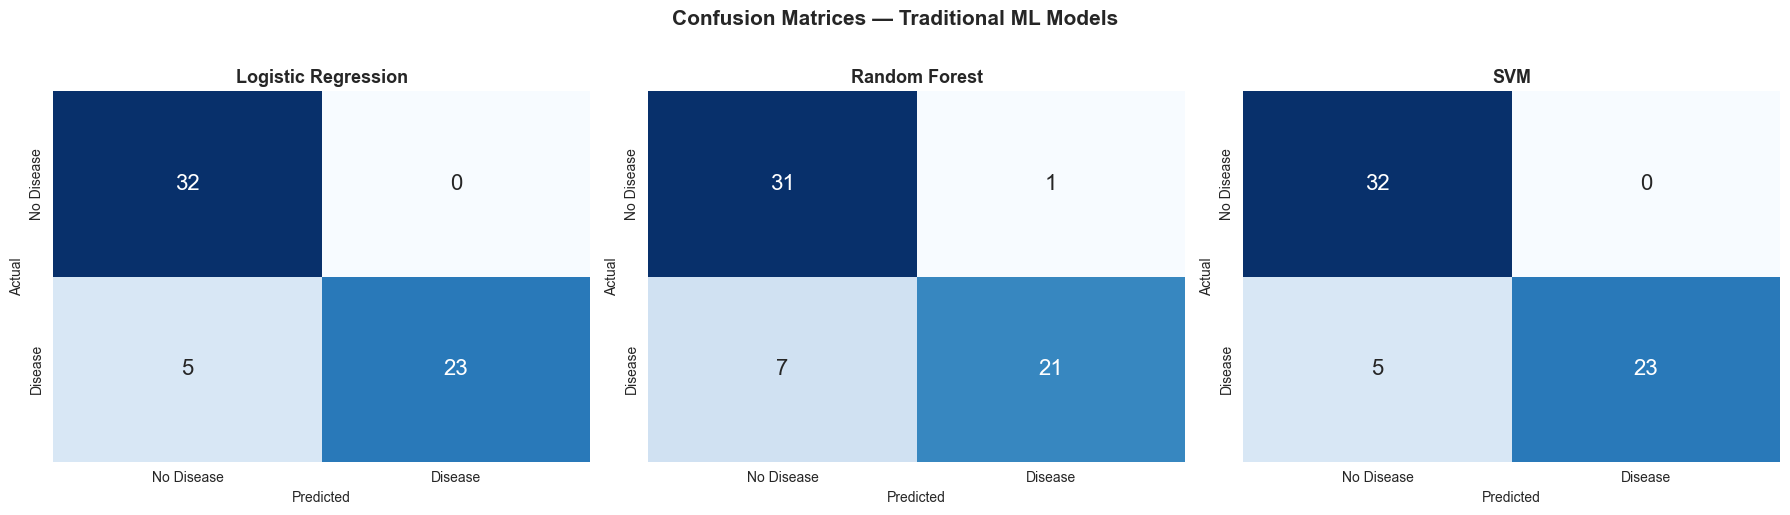

In [9]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Logistic Regression', lr_pred, axes[0]),
    ('Random Forest',       rf_pred, axes[1]),
    ('SVM',                 svm_pred, axes[2]),
]

for name, pred, ax in models_info:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                cbar=False, annot_kws={'size': 16})
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Traditional ML Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/12_confusion_matrices_ml.png', dpi=100, bbox_inches='tight')
plt.show()

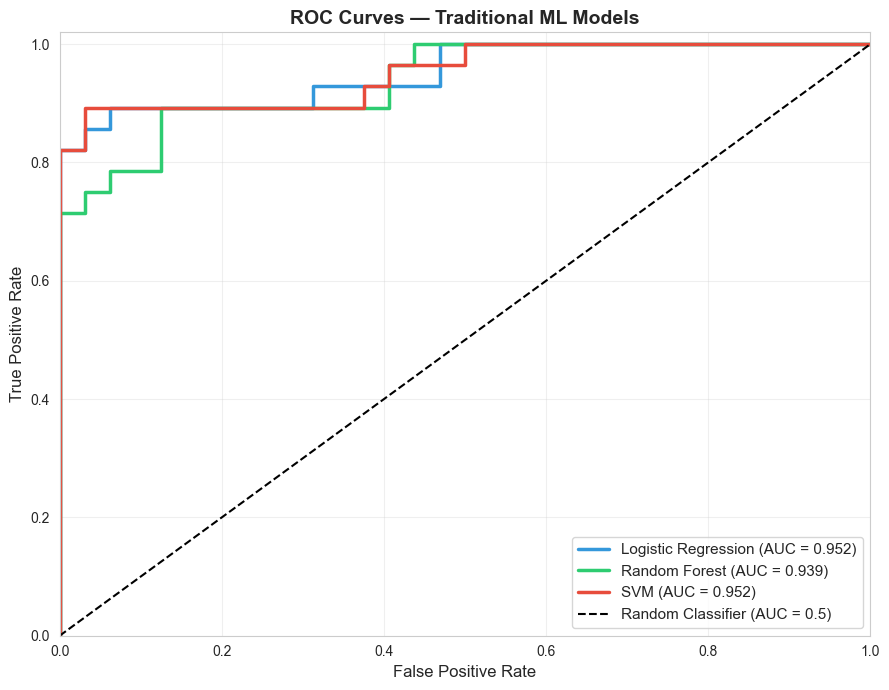

In [10]:
# ROC curves for all three models
plt.figure(figsize=(9, 7))

models_roc = [
    ('Logistic Regression', lr_pred_proba, '#3498db'),
    ('Random Forest',       rf_pred_proba, '#2ecc71'),
    ('SVM',                 svm_pred_proba, '#e74c3c'),
]

for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.3f})')

# Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Traditional ML Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/13_roc_curves_ml.png', dpi=100, bbox_inches='tight')
plt.show()

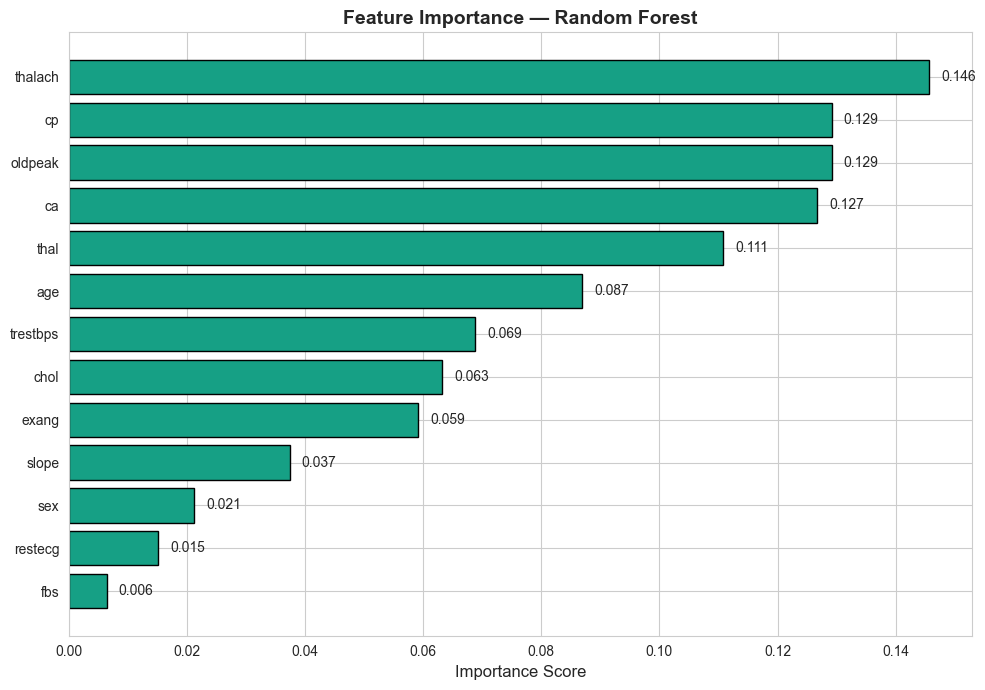


Top 5 most important features:
    Feature  Importance
7   thalach    0.145678
2        cp    0.129175
9   oldpeak    0.129162
11       ca    0.126748
12     thal    0.110818


In [11]:
# Feature importance from Random Forest
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)  # Ascending so largest is at top in horizontal bar

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importances['Feature'], feature_importances['Importance'], 
                color='#16a085', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/plots/14_feature_importance_rf.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feature_importances.sort_values('Importance', ascending=False).head())

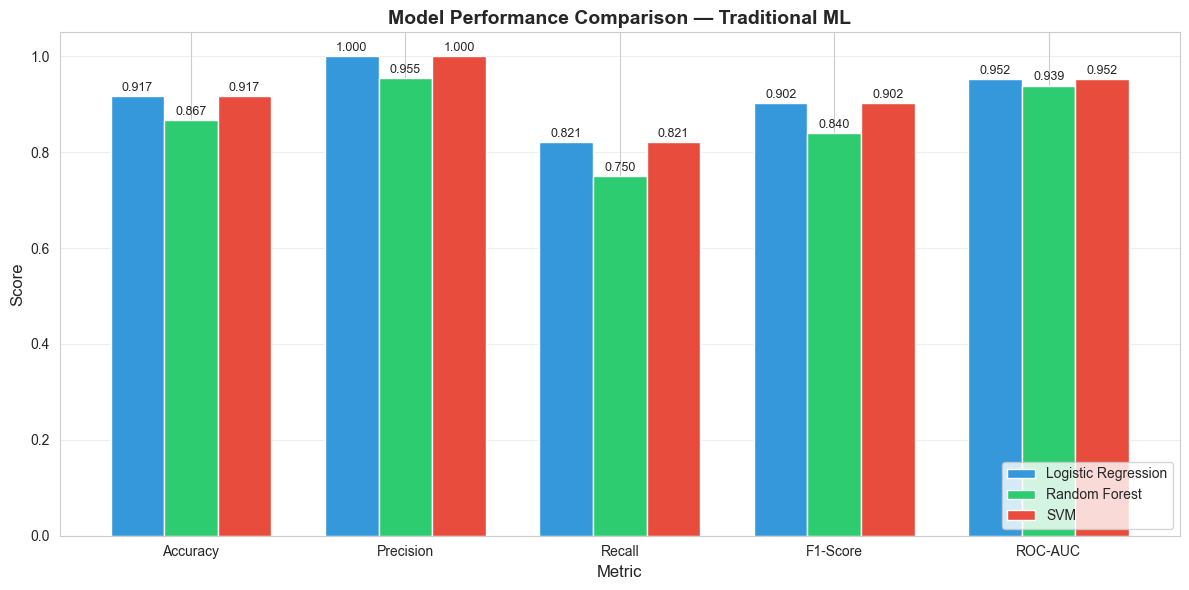

In [12]:
# Bar chart comparing all metrics across models
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

lr_scores  = [results_df.loc['Logistic Regression', m] for m in metrics_to_plot]
rf_scores  = [results_df.loc['Random Forest',       m] for m in metrics_to_plot]
svm_scores = [results_df.loc['SVM',                 m] for m in metrics_to_plot]

bars1 = ax.bar(x - width, lr_scores,  width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x,         rf_scores,  width, label='Random Forest',       color='#2ecc71')
bars3 = ax.bar(x + width, svm_scores, width, label='SVM',                 color='#e74c3c')

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Traditional ML', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/plots/15_model_comparison_bar.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
import pickle
import os

os.makedirs('../outputs/models', exist_ok=True)

# Save all three models
with open('../outputs/models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('../outputs/models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('../outputs/models/svm.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# Save predictions for comparison in Notebook 3
predictions_df = pd.DataFrame({
    'y_test': y_test.values,
    'lr_pred': lr_pred,
    'lr_proba': lr_pred_proba,
    'rf_pred': rf_pred,
    'rf_proba': rf_pred_proba,
    'svm_pred': svm_pred,
    'svm_proba': svm_pred_proba,
})
predictions_df.to_csv('../outputs/processed_data/ml_predictions.csv', index=False)

print("Models and predictions saved.")

Models and predictions saved.


Notebook 2 Summary

Models trained
- Logistic Regression — linear baseline
- Random Forest (200 trees, max_depth=8) — tree-based ensemble
- SVM (RBF kernel) — non-linear margin-based

Evaluation completed for all models
- Accuracy, Precision, Recall, F1-score, ROC-AUC
- Confusion matrices
- Per-class classification reports

Visualizations produced
- Confusion matrices side by side
- ROC curves comparison
- Random Forest feature importance
- Bar chart comparing all metrics across models

Key observations
- All three models achieved strong performance (accuracy > 0.80)
- Feature importance and correlation analysis agree on the top predictors: `cp`, `thalach`, `oldpeak`, `ca`, `thal`
- ROC-AUC values above 0.85 indicate good discriminative ability